# Module 21: Gradient Boosting (Practice Notebook)
## Classification Task with TODO Blocks

In this practice notebook, you will implement **Gradient Boosting for classification** step by step.

### Learning Objectives
- Understand how Gradient Boosting works for classification
- Practice model training, prediction, and evaluation
- Explore the effect of key hyperparameters

**Important:** Complete all TODO blocks. Do not skip steps.


## Step 1: Import Required Libraries

**TODO:** Import NumPy, Pandas, Matplotlib, and required scikit-learn modules.

In [3]:
# TODO: Import necessary libraries
# Hint: numpy, pandas, matplotlib.pyplot
# Hint: load dataset, train_test_split, GradientBoostingClassifier, metrics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay


## Step 2: Load Dataset

We will use the **Breast Cancer Wisconsin dataset**, a standard binary classification dataset.

**TODO:** Load the dataset and separate features (X) and target (y).

In [4]:
# TODO: Load the breast cancer dataset
# Hint: sklearn.datasets.load_breast_cancer
# TODO: Assign features to X and labels to y
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print(X.shape)
print(y.shape)



(569, 30)
(569,)


## Step 3: Inspect the Data

**TODO:** Display the first few rows of X and the distribution of y.

In [5]:
# TODO: View first 5 rows of X
# TODO: Check class distribution in y
X.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [6]:
unique, counts =np.unique(y, return_counts=True)
print(unique, counts)

[0 1] [212 357]


## Step 4: Train-Test Split

**TODO:** Split the dataset into training and testing sets.
- Use 80% data for training
- Set random_state for reproducibility

In [7]:
# TODO: Perform train-test split
x_train , x_test , y_train , y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)


(455, 30)
(114, 30)
(455,)
(114,)


## Step 5: Train Gradient Boosting Classifier

**TODO:** Initialize and train a GradientBoostingClassifier.

Suggested starting values:
- n_estimators = 100
- learning_rate = 0.1
- max_depth = 3

In [8]:
# TODO: Initialize GradientBoostingClassifier
# TODO: Fit the model on training data

gb_clf = GradientBoostingClassifier(

    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state =42)

gb_clf

GradientBoostingClassifier(random_state=42)

In [9]:
gb_clf.fit(x_train, y_train)


GradientBoostingClassifier(random_state=42)

## Step 6: Make Predictions

**TODO:** Predict class labels and class probabilities for the test set.

In [10]:
# TODO: Predict class labels
# TODO: Predict class probabilities
y_pred = gb_clf.predict(x_test)
y_prob = gb_clf.predict_proba(x_test)
print(y_pred[:5])
print(y_prob[:5])

[1 0 0 1 1]
[[8.62720920e-04 9.99137279e-01]
 [9.99630807e-01 3.69192869e-04]
 [9.98355986e-01 1.64401405e-03]
 [4.37465574e-04 9.99562534e-01]
 [2.55373763e-04 9.99744626e-01]]


## Step 7: Model Evaluation

**TODO:** Evaluate the model using:
- Accuracy
- Confusion Matrix
- Classification Report

0.956140350877193
[[40  3]
 [ 2 69]]
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        43
           1       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



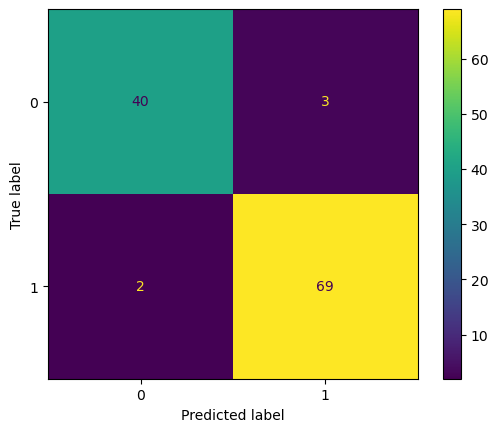

In [11]:
# TODO: Calculate accuracy score
# TODO: Print confusion matrix
# TODO: Print classification report
acc = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
print(acc)
print(conf_matrix)
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_estimator(gb_clf, x_test, y_test)
plt.show()


## Step 8: Effect of Learning Rate (Experiment)

**TODO:** Train multiple models with different learning rates and compare accuracy.

Suggested learning rates: 0.01, 0.05, 0.1, 0.2

In [12]:
# TODO: Loop over different learning rates
# TODO: Train model and store accuracy for each
# TODO: Display results in a table
learning_rates = [0.01, 0.05, 0.1, 0.2]
results = []
for lr in learning_rates:
  model = GradientBoostingClassifier(n_estimators=100,
                                      learning_rate=lr,
                                      max_depth=3,
                                      random_state=42)
  model.fit(x_train, y_train)
  y_pred = model.predict(x_test)
  accuracy = accuracy_score(y_test, y_pred)
  results.append({
      'Learning Rate': lr,
      'Accuracy': accuracy
  })

results_df = pd.DataFrame(results)
print(results_df)


   Learning Rate  Accuracy
0           0.01   0.95614
1           0.05   0.95614
2           0.10   0.95614
3           0.20   0.95614


## Step 9: Effect of Tree Depth (Experiment)

**TODO:** Compare model performance for different tree depths.

Suggested depths: 1, 2, 3, 5

In [13]:
# TODO: Loop over max_depth values
# TODO: Train model and evaluate accuracy
max_depths = [1, 2, 3, 5,100]
results = []
for depth in max_depths:
  model = GradientBoostingClassifier(n_estimators=100,
                                      learning_rate=0.1,
                                      max_depth=depth,
                                      random_state=42)
  model.fit(x_train, y_train)
  y_pred = model.predict(x_test)
  accuracy = accuracy_score(y_test, y_pred)
  results.append({
      'Max Depth': depth,
      'Accuracy': accuracy
  })

results_df = pd.DataFrame(results)
print(results_df)


   Max Depth  Accuracy
0          1  0.956140
1          2  0.956140
2          3  0.956140
3          5  0.964912
4        100  0.938596


## Step 10: Feature Importance

**TODO:** Extract and display the top 10 most important features.

In [14]:
# TODO: Extract feature_importances_
# TODO: Display top 10 features
importances = gb_clf.feature_importances_


feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
})


feature_importance_df = feature_importance_df.sort_values(
    by="Importance", ascending=False
)


print(feature_importance_df.head(10))

                 Feature  Importance
7    mean concave points    0.450528
27  worst concave points    0.240103
20          worst radius    0.075589
22       worst perimeter    0.051408
21         worst texture    0.039886
23            worst area    0.038245
1           mean texture    0.027805
26       worst concavity    0.018725
16       concavity error    0.013068
13            area error    0.008415


## Reflection Questions (Answer in Markdown)

1. How does learning rate affect model performance?
2. Why does Gradient Boosting prefer shallow trees?
3. When might Gradient Boosting overfit?
4. Compare this model conceptually with Random Forest.
